# 📕 Pre-Workshop Notebook 6: Putting It All Together — Your Complete Research Workflow
## Scientific Workflows for Brain and Behavioral Research
### National Science Foundation Supported Learning Initiative (Award No. OAC-2417875)

---

## 📋 Final Portfolio Setup
*Run the cell below to generate your portfolio registration header.*

In [1]:
# FINAL PORTFOLIO SETUP
student_name = "Dr. Evie A. Malaia"
institution = "University of Alabama"
completion_date = "2026-08-13"

print(f"🎓 Portfolio record generated for: {student_name} ({institution})")
print(f"📅 Date: {completion_date}")
print("✅ Pre-Workshop Notebooks 01 through 05 confirmed complete.")

🎓 Portfolio record generated for: Dr. Evie A. Malaia (University of Alabama)
📅 Date: 2026-08-13
✅ Pre-Workshop Notebooks 01 through 05 confirmed complete.


---

## 🤖 Using AI Tools to Build Your Workflow ("Ask → Build → Document")

As a **Workflow Designer** completing your capstone integration, your final challenge is making sure all four stages of your workflow connect properly. Individual stages designed separately sometimes pass data in formats that the next stage does not expect — causing silent errors that are hard to spot.

When using the **Ask → Build → Document** cycle in this notebook, ask the AI to add clear status messages between each stage so you can confirm that data is being passed correctly from one step to the next.

---
## 🧠 Part A: Building a Complete Four-Stage Research Workflow
### Topic: Connecting All Stages from Data Loading to Visualization

This notebook brings together everything from Notebooks 1 through 4. You will build a single integrated workflow that connects all four stages — Obtaining Data, Analyzing Data, Visualizing Results, and Documenting Research — into one complete, working pipeline.

### 🧭 Activity A.1 — The Complete Integrated Research Workflow

> *Copy the prompt below into your preferred AI tool, then paste the generated code into the code cell beneath it.*
>
> "Act as a lead neuroscience workflow designer helping a research team build their first complete end-to-end analysis pipeline. Write a single Python script that connects four completely independent, clearly separated stages into one working workflow. The script should:
> 1. Stage 1 — Obtaining Data: Generate a simulated 64-channel brain recording with realistic background noise and some sudden movement artifacts. This stage should not perform any analysis or create any plots.
> 2. Stage 2 — Analyzing Data: Accept the raw data from Stage 1 and clean it using an automated threshold to remove the movement artifacts, without modifying the original data. Then extract key summary features from the cleaned signal.
> 3. Stage 3 — Visualizing Results: Accept the processed features from Stage 2 and create a high-quality figure showing the raw versus cleaned signal side-by-side, along with a summary of the extracted features.
> 4. Stage 4 — Documenting Research: Record the analysis settings used, the processing time for each stage, and any errors that were caught — saving this information to a structured log file.
> Add error-handling safeguards around each stage so that if one stage encounters a problem, it logs the issue and the other stages can still run. Include clear status messages between stages confirming that data passed correctly from one stage to the next."


STAGE 1 — OBTAINING DATA
SUCCESS: Raw 64-channel recording generated.
Data shape: (64, 2000)
STATUS: Data passed successfully to Stage 2.

STAGE 2 — ANALYZING DATA
SUCCESS: Raw data was cleaned without modifying the original recording.
Artifacts detected: 3322
Artifact percentage: 2.595%
STATUS: Processed data and features passed successfully to Stage 3.

STAGE 3 — VISUALIZING RESULTS


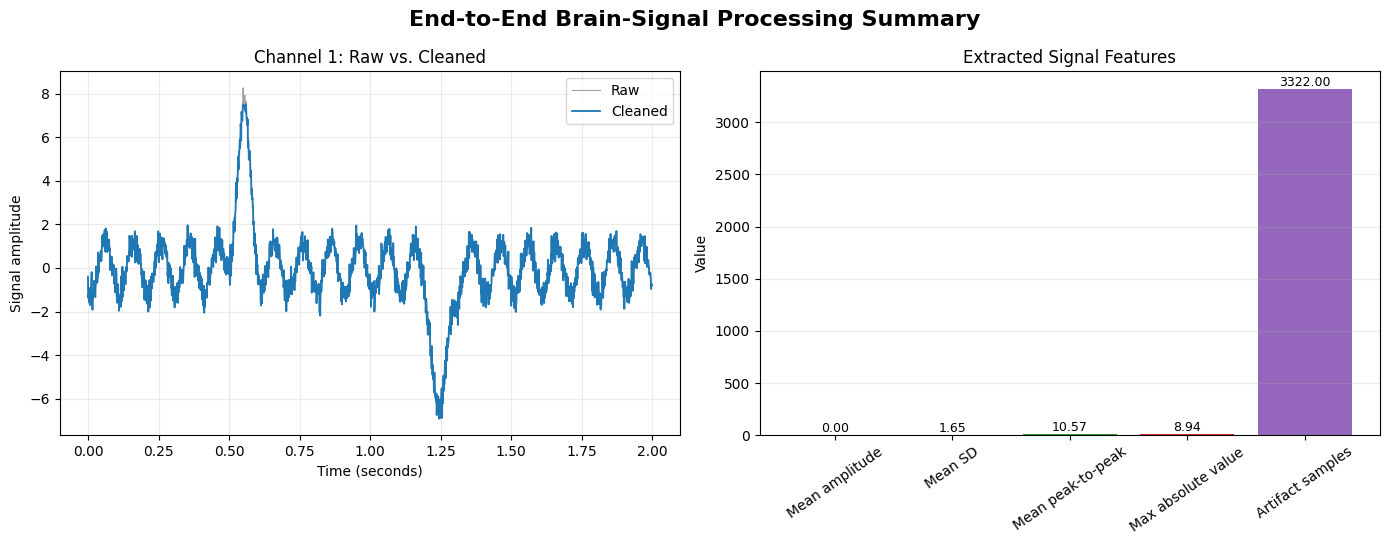

SUCCESS: Figure saved to brain_workflow_summary.png
STATUS: Visualization completed successfully.

STAGE 4 — DOCUMENTING RESEARCH
SUCCESS: Research log saved to brain_workflow_log.json
STATUS: Workflow documentation completed.

WORKFLOW COMPLETE

Successful stages: 4
Errors recorded: 0

The workflow did not terminate simply because one stage encountered an error.
The structured research log records what happened.


In [2]:
# 💻 Activity A.1 — Paste your AI-generated Complete Research Workflow code here:
"""
End-to-end neuroscience analysis workflow

Four independent stages:

    Stage 1: Obtaining Data
        Generate a simulated 64-channel brain recording.

    Stage 2: Analyzing Data
        Detect and remove movement artifacts without changing
        the original recording, then calculate summary features.

    Stage 3: Visualizing Results
        Create a publication-style figure from the results.

    Stage 4: Documenting Research
        Record settings, timing, and errors in a JSON log.

The separation makes the workflow easier to test, modify,
debug, and reproduce.
"""

import json
import time
from datetime import datetime

import numpy as np
import matplotlib.pyplot as plt


# ============================================================
# WORKFLOW SETTINGS
# ============================================================

SETTINGS = {
    "n_channels": 64,
    "sampling_rate_hz": 1000,
    "duration_seconds": 2,
    "brain_frequency_hz": 10,
    "artifact_threshold": 6.0,
    "random_seed": 42,
    "output_figure": "brain_workflow_summary.png",
    "output_log": "brain_workflow_log.json",
}


# ============================================================
# STAGE 1 — OBTAINING DATA
# ============================================================
#
# Responsibility:
#   Generate or load raw data.
#
# This function deliberately does NOT:
#   - clean the data
#   - calculate analysis statistics
#   - create plots
#
# Keeping data acquisition separate means that later we could
# replace this simulation with a function that loads a real
# EEG/brain-recording file without rewriting the analysis code.
# ============================================================

def stage1_obtain_data(settings):
    """Generate a simulated multichannel brain recording."""

    n_channels = settings["n_channels"]
    sampling_rate = settings["sampling_rate_hz"]
    duration = settings["duration_seconds"]
    brain_frequency = settings["brain_frequency_hz"]
    seed = settings["random_seed"]

    rng = np.random.default_rng(seed)

    n_samples = int(
        sampling_rate * duration
    )

    time_axis = np.arange(n_samples) / sampling_rate

    # Each channel contains a slightly different 10 Hz rhythm.
    # This is a simplified representation of rhythmic neural
    # activity rather than a realistic full EEG model.
    channel_amplitudes = rng.uniform(
        0.6,
        1.4,
        size=n_channels
    )

    channel_phases = rng.uniform(
        0,
        2 * np.pi,
        size=n_channels
    )

    brain_activity = np.zeros(
        (n_channels, n_samples)
    )

    for channel in range(n_channels):

        brain_activity[channel] = (
            channel_amplitudes[channel]
            * np.sin(
                2 * np.pi * brain_frequency * time_axis
                + channel_phases[channel]
            )
        )

    # Add realistic-looking background noise.
    background_noise = rng.normal(
        0,
        0.35,
        size=(n_channels, n_samples)
    )

    raw_data = (
        brain_activity
        + background_noise
    )

    # --------------------------------------------------------
    # Add several sudden movement artifacts.
    # --------------------------------------------------------
    #
    # A movement can affect many electrodes simultaneously.
    # We therefore add a large transient to multiple channels.
    #
    # These artifacts are intentionally much larger than the
    # normal neural signal so that our automated detector can
    # identify them later.
    # --------------------------------------------------------

    artifact_times = [
        0.55,
        1.25,
        1.70,
    ]

    artifact_width_seconds = 0.025

    for artifact_time in artifact_times:

        distance = (
            time_axis - artifact_time
        )

        artifact_shape = np.exp(
            -(distance ** 2)
            / (
                2 * artifact_width_seconds ** 2
            )
        )

        # Most, but not necessarily all, channels are affected.
        affected_channels = rng.choice(
            n_channels,
            size=int(n_channels * 0.75),
            replace=False
        )

        for channel in affected_channels:

            amplitude = rng.uniform(
                5.0,
                10.0
            )

            # Random sign makes artifacts less uniform.
            sign = rng.choice([-1, 1])

            raw_data[channel] += (
                sign
                * amplitude
                * artifact_shape
            )

    return {
        "data": raw_data,
        "time": time_axis,
    }


# ============================================================
# STAGE 2 — ANALYZING DATA
# ============================================================
#
# Responsibility:
#   Receive raw data, clean it, and calculate features.
#
# IMPORTANT:
#   raw_data is NEVER modified.
#
# We create a separate copy called cleaned_data.
#
# The artifact detector uses a robust threshold based on the
# median and median absolute deviation (MAD). This makes the
# threshold less sensitive to the unusually large artifacts
# themselves.
#
# After detecting artifact samples, we interpolate across them
# using nearby clean samples.
# ============================================================

def stage2_analyze_data(stage1_output, settings):
    """Clean the recording and calculate summary features."""

    raw_data = stage1_output["data"]
    time_axis = stage1_output["time"]

    # Make a completely independent copy.
    #
    # This protects the original recording and preserves the
    # raw measurements for later inspection or re-analysis.
    cleaned_data = raw_data.copy()

    threshold_multiplier = settings[
        "artifact_threshold"
    ]

    n_channels, n_samples = raw_data.shape

    # --------------------------------------------------------
    # Calculate a robust threshold for every channel.
    # --------------------------------------------------------

    channel_medians = np.median(
        raw_data,
        axis=1,
        keepdims=True
    )

    absolute_deviation = np.abs(
        raw_data - channel_medians
    )

    mad = np.median(
        absolute_deviation,
        axis=1,
        keepdims=True
    )

    # Convert MAD to an approximate standard-deviation scale.
    robust_std = 1.4826 * mad

    # Prevent a completely flat channel from producing a
    # zero threshold.
    robust_std = np.maximum(
        robust_std,
        1e-8
    )

    # A sample is considered suspicious when it is many robust
    # standard deviations away from the channel's median.
    threshold = (
        threshold_multiplier
        * robust_std
    )

    artifact_mask = (
        np.abs(
            raw_data - channel_medians
        )
        > threshold
    )

    # --------------------------------------------------------
    # Remove detected artifacts using interpolation.
    # --------------------------------------------------------

    total_artifact_samples = int(
        np.sum(artifact_mask)
    )

    for channel in range(n_channels):

        bad = artifact_mask[channel]
        good = ~bad

        # Interpolation requires at least two clean samples.
        if np.sum(good) >= 2 and np.any(bad):

            cleaned_data[channel, bad] = np.interp(
                time_axis[bad],
                time_axis[good],
                raw_data[channel, good]
            )

    # --------------------------------------------------------
    # Extract summary features from the cleaned recording.
    # --------------------------------------------------------
    #
    # These features summarize the cleaned signal without
    # replacing the original recording.
    # --------------------------------------------------------

    channel_means = np.mean(
        cleaned_data,
        axis=1
    )

    channel_std = np.std(
        cleaned_data,
        axis=1
    )

    channel_peak_to_peak = (
        np.ptp(
            cleaned_data,
            axis=1
        )
    )

    features = {
        "mean_amplitude": float(
            np.mean(channel_means)
        ),
        "mean_standard_deviation": float(
            np.mean(channel_std)
        ),
        "mean_peak_to_peak": float(
            np.mean(channel_peak_to_peak)
        ),
        "maximum_absolute_value": float(
            np.max(np.abs(cleaned_data))
        ),
        "artifact_samples_detected": (
            total_artifact_samples
        ),
        "artifact_percentage": (
            100
            * total_artifact_samples
            / raw_data.size
        ),
    }

    # These channel-level values are useful for the visualization.
    features["channel_standard_deviations"] = (
        channel_std
    )

    return {
        "raw_data": raw_data,
        "cleaned_data": cleaned_data,
        "time": time_axis,
        "artifact_mask": artifact_mask,
        "features": features,
    }


# ============================================================
# STAGE 3 — VISUALIZING RESULTS
# ============================================================
#
# Responsibility:
#   Take the processed output from Stage 2 and create figures.
#
# It does not perform the artifact detection itself.
#
# The figure contains:
#
#   Left:  one representative raw channel
#          versus its cleaned version.
#
#   Right: summary of extracted features.
#
# The raw and cleaned signals are plotted together so that the
# effect of artifact removal is easy to inspect.
# ============================================================

def stage3_visualize_results(stage2_output, settings):
    """Create a high-quality summary figure."""

    raw_data = stage2_output["raw_data"]
    cleaned_data = stage2_output["cleaned_data"]
    time_axis = stage2_output["time"]
    features = stage2_output["features"]

    # Use channel 0 as an easy-to-read representative example.
    channel_to_plot = 0

    figure, axes = plt.subplots(
        1,
        2,
        figsize=(14, 5.5)
    )

    # --------------------------------------------------------
    # Left panel: raw versus cleaned signal
    # --------------------------------------------------------

    axes[0].plot(
        time_axis,
        raw_data[channel_to_plot],
        color="gray",
        linewidth=0.8,
        alpha=0.75,
        label="Raw"
    )

    axes[0].plot(
        time_axis,
        cleaned_data[channel_to_plot],
        color="tab:blue",
        linewidth=1.3,
        label="Cleaned"
    )

    axes[0].set_title(
        f"Channel {channel_to_plot + 1}: "
        "Raw vs. Cleaned"
    )

    axes[0].set_xlabel(
        "Time (seconds)"
    )

    axes[0].set_ylabel(
        "Signal amplitude"
    )

    axes[0].legend()

    axes[0].grid(
        alpha=0.25
    )

    # --------------------------------------------------------
    # Right panel: extracted features
    # --------------------------------------------------------

    feature_names = [
        "Mean amplitude",
        "Mean SD",
        "Mean peak-to-peak",
        "Max absolute value",
        "Artifact samples",
    ]

    feature_values = [
        features["mean_amplitude"],
        features["mean_standard_deviation"],
        features["mean_peak_to_peak"],
        features["maximum_absolute_value"],
        features["artifact_samples_detected"],
    ]

    bars = axes[1].bar(
        feature_names,
        feature_values,
        color=[
            "tab:blue",
            "tab:orange",
            "tab:green",
            "tab:red",
            "tab:purple",
        ]
    )

    axes[1].set_title(
        "Extracted Signal Features"
    )

    axes[1].set_ylabel(
        "Value"
    )

    axes[1].tick_params(
        axis="x",
        rotation=35
    )

    axes[1].grid(
        axis="y",
        alpha=0.25
    )

    # Add numerical values above the bars.
    for bar, value in zip(
        bars,
        feature_values
    ):

        axes[1].text(
            bar.get_x()
            + bar.get_width() / 2,
            bar.get_height(),
            f"{value:.2f}",
            ha="center",
            va="bottom",
            fontsize=9
        )

    figure.suptitle(
        "End-to-End Brain-Signal Processing Summary",
        fontsize=16,
        fontweight="bold"
    )

    figure.tight_layout()

    figure.savefig(
        settings["output_figure"],
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

    return settings["output_figure"]


# ============================================================
# STAGE 4 — DOCUMENTING RESEARCH
# ============================================================
#
# Responsibility:
#   Save a structured record of:
#
#       - settings
#       - stage status
#       - processing times
#       - errors
#       - output files
#
# JSON is used because it is structured and easy for both
# humans and computers to read.
# ============================================================

def stage4_document_research(
    settings,
    stage_records,
    errors,
    output_files
):
    """Save a structured research workflow log."""

    log_record = {
        "workflow": (
            "End-to-end simulated neuroscience analysis"
        ),
        "timestamp": datetime.now().isoformat(),
        "settings": settings,
        "stages": stage_records,
        "errors": errors,
        "output_files": output_files,
    }

    with open(
        settings["output_log"],
        "w",
        encoding="utf-8"
    ) as file:

        json.dump(
            log_record,
            file,
            indent=4
        )

    return log_record


# ============================================================
# MAIN WORKFLOW CONTROLLER
# ============================================================
#
# This part connects the four independent stages.
#
# Each stage has its own try/except block.
#
# Therefore:
#
#   Stage 1 failure does not crash the entire program.
#   Stage 2 failure is recorded and Stage 3 can still attempt
#       to create an informative fallback figure.
#   Stage 3 failure is recorded.
#   Stage 4 is attempted regardless so that the failure itself
#       can be documented.
# ============================================================

def run_workflow():

    stage_records = []
    errors = []
    output_files = []

    stage1_output = None
    stage2_output = None

    # --------------------------------------------------------
    # STAGE 1
    # --------------------------------------------------------

    print("\n" + "=" * 65)
    print("STAGE 1 — OBTAINING DATA")
    print("=" * 65)

    start_time = time.perf_counter()

    try:

        stage1_output = stage1_obtain_data(
            SETTINGS
        )

        elapsed = (
            time.perf_counter()
            - start_time
        )

        stage_records.append({
            "stage": "Stage 1 — Obtaining Data",
            "status": "success",
            "processing_time_seconds": elapsed,
        })

        print(
            "SUCCESS: Raw 64-channel recording generated."
        )

        print(
            f"Data shape: "
            f"{stage1_output['data'].shape}"
        )

        print(
            "STATUS: Data passed successfully to Stage 2."
        )

    except Exception as error:

        elapsed = (
            time.perf_counter()
            - start_time
        )

        message = (
            f"Stage 1 failed: "
            f"{type(error).__name__}: {error}"
        )

        print(
            "ERROR:",
            message
        )

        errors.append(message)

        stage_records.append({
            "stage": "Stage 1 — Obtaining Data",
            "status": "failed",
            "processing_time_seconds": elapsed,
        })


    # --------------------------------------------------------
    # STAGE 2
    # --------------------------------------------------------

    print("\n" + "=" * 65)
    print("STAGE 2 — ANALYZING DATA")
    print("=" * 65)

    start_time = time.perf_counter()

    try:

        if stage1_output is None:
            raise RuntimeError(
                "Stage 1 produced no data."
            )

        stage2_output = stage2_analyze_data(
            stage1_output,
            SETTINGS
        )

        elapsed = (
            time.perf_counter()
            - start_time
        )

        stage_records.append({
            "stage": "Stage 2 — Analyzing Data",
            "status": "success",
            "processing_time_seconds": elapsed,
        })

        features = stage2_output["features"]

        print(
            "SUCCESS: Raw data was cleaned without "
            "modifying the original recording."
        )

        print(
            "Artifacts detected:",
            features["artifact_samples_detected"]
        )

        print(
            f"Artifact percentage: "
            f"{features['artifact_percentage']:.3f}%"
        )

        print(
            "STATUS: Processed data and features "
            "passed successfully to Stage 3."
        )

    except Exception as error:

        elapsed = (
            time.perf_counter()
            - start_time
        )

        message = (
            f"Stage 2 failed: "
            f"{type(error).__name__}: {error}"
        )

        print(
            "ERROR:",
            message
        )

        errors.append(message)

        stage_records.append({
            "stage": "Stage 2 — Analyzing Data",
            "status": "failed",
            "processing_time_seconds": elapsed,
        })


    # --------------------------------------------------------
    # STAGE 3
    # --------------------------------------------------------

    print("\n" + "=" * 65)
    print("STAGE 3 — VISUALIZING RESULTS")
    print("=" * 65)

    start_time = time.perf_counter()

    try:

        if stage2_output is None:
            raise RuntimeError(
                "Stage 2 produced no processed results."
            )

        figure_file = stage3_visualize_results(
            stage2_output,
            SETTINGS
        )

        output_files.append(
            figure_file
        )

        elapsed = (
            time.perf_counter()
            - start_time
        )

        stage_records.append({
            "stage": "Stage 3 — Visualizing Results",
            "status": "success",
            "processing_time_seconds": elapsed,
        })

        print(
            f"SUCCESS: Figure saved to {figure_file}"
        )

        print(
            "STATUS: Visualization completed successfully."
        )

    except Exception as error:

        elapsed = (
            time.perf_counter()
            - start_time
        )

        message = (
            f"Stage 3 failed: "
            f"{type(error).__name__}: {error}"
        )

        print(
            "ERROR:",
            message
        )

        errors.append(message)

        stage_records.append({
            "stage": "Stage 3 — Visualizing Results",
            "status": "failed",
            "processing_time_seconds": elapsed,
        })


    # --------------------------------------------------------
    # STAGE 4
    # --------------------------------------------------------
    #
    # This stage is deliberately attempted even when earlier
    # stages failed. Documentation of a failed run is still
    # valuable because it tells researchers what happened.
    # --------------------------------------------------------

    print("\n" + "=" * 65)
    print("STAGE 4 — DOCUMENTING RESEARCH")
    print("=" * 65)

    start_time = time.perf_counter()

    try:

        log_record = stage4_document_research(
            SETTINGS,
            stage_records,
            errors,
            output_files
        )

        elapsed = (
            time.perf_counter()
            - start_time
        )

        stage_records.append({
            "stage": "Stage 4 — Documenting Research",
            "status": "success",
            "processing_time_seconds": elapsed,
        })

        # Update the log once more so its own processing time is
        # included in the final record.
        stage4_document_research(
            SETTINGS,
            stage_records,
            errors,
            output_files
        )

        print(
            f"SUCCESS: Research log saved to "
            f"{SETTINGS['output_log']}"
        )

        print(
            "STATUS: Workflow documentation completed."
        )

    except Exception as error:

        elapsed = (
            time.perf_counter()
            - start_time
        )

        message = (
            f"Stage 4 failed: "
            f"{type(error).__name__}: {error}"
        )

        print(
            "ERROR:",
            message
        )

        errors.append(message)

        stage_records.append({
            "stage": "Stage 4 — Documenting Research",
            "status": "failed",
            "processing_time_seconds": elapsed,
        })


    # --------------------------------------------------------
    # Final workflow report
    # --------------------------------------------------------

    print("\n" + "=" * 65)
    print("WORKFLOW COMPLETE")
    print("=" * 65)

    successful_stages = sum(
        record["status"] == "success"
        for record in stage_records
    )

    print(
        f"\nSuccessful stages: "
        f"{successful_stages}"
    )

    print(
        f"Errors recorded: "
        f"{len(errors)}"
    )

    print(
        "\nThe workflow did not terminate simply because "
        "one stage encountered an error."
    )

    print(
        "The structured research log records what happened."
    )


# ============================================================
# RUN THE COMPLETE PIPELINE
# ============================================================

if __name__ == "__main__":

    run_workflow()


### ✍️ Part A Reflection
*Double-click this cell to write your response.*

* **What I observed:** Look at the status messages printed between stages. Did each stage receive data in the format it expected? Were any errors caught and logged? - yep. No errors.
* **Connecting to key concepts:** This integrated workflow demonstrates mastery of all 50 concepts in the Reference Guide. In your own words, describe what happens if Stage 2 (Analyzing Data) tries to pass its results to Stage 3 (Visualizing Results) in the wrong format — and how the error-handling safeguards in the workflow help you find this quickly. - The error is  added to the  log, saying which stage failed and what kind of problem occurred.

---

## 📑 You Are Ready for the Onsite Workshop

Completing this notebook means you have worked through all six foundational areas:

1. **Notebook 1:** How brain and behavioral data is captured and how computers organize it
2. **Notebook 2:** Working with larger datasets and running analyses efficiently
3. **Notebook 3:** Accessing national research computing resources and connecting securely
4. **Notebook 4:** Cleaning signals and building reliable workflows
5. **Notebook 5:** Finding patterns and making workflows reproducible
6. **Notebook 6:** Connecting all four stages into a complete integrated workflow

The onsite workshop will apply these foundations across three progressively more demanding scenarios — a single-participant workflow, a group of 50 participants, and finally a small portable edge device. Everything you have practiced here will be directly relevant.


---

## 📖 Reference Guide: 50 Key Concepts for Neuroscience Workflows

Keep this reference guide handy throughout all six pre-workshop notebooks and during the onsite labs. These concepts form the foundation of the workshop's hands-on activities.

### 🧠 Neuroscience & Research Applications (Concepts 1–25)
1. **Brain-Machine Interface (BMI):** A system that connects the brain directly to an external device — bypassing damaged nerves or muscles — so that brain signals can control a robotic limb, cursor, or other tool.
2. **Non-Invasive (EEG) vs. Invasive (Intracortical) Sensors:** Scalp electrodes (EEG) are easy to use but pick up blurry, averaged signals through the skull. Implanted microelectrode arrays record from individual neurons with much greater precision, but require surgery.
3. **Signal Delay (Latency):** The time gap between a brain signal being recorded and a device responding to it. Delays longer than about 50–100 milliseconds feel unnatural to the user of a prosthetic device.
4. **Decoder:** A mathematical or statistical model that translates continuous brain signal patterns into a useful output — such as movement direction, cursor position, or speech intent.
5. **fMRI:** Functional Magnetic Resonance Imaging — a brain scanning method that measures blood oxygen levels as a stand-in for neural activity. When neurons become active, they consume more oxygen, causing a detectable change in the local blood signal.
6. **Voxel:** A small 3D cube of brain tissue in an fMRI image — the brain-imaging equivalent of a pixel. Each voxel contains millions of neurons.
7. **Head Movement Correction:** A processing step that aligns brain scan images across time, compensating for small movements the participant made during the recording session.
8. **Open-Loop vs. Closed-Loop Systems:** An open-loop device follows a fixed program regardless of what the user's brain is doing. A closed-loop device continuously reads incoming signals and adjusts its output in real time based on what it detects.
9. **Deep Brain Stimulation (DBS):** A treatment for conditions like Parkinson's disease in which a small implanted device delivers electrical pulses to specific brain regions to reduce tremor and improve movement.
10. **EMG (Electromyogram):** A recording of the electrical signals produced by muscles when they contract. Often used alongside brain recordings to verify whether a behavioral response actually occurred.
11. **Continuous Recordings vs. Event Markers:** A continuous recording captures an uninterrupted time series of measurements. Event markers are specific timestamps that label when something important happened — such as when a stimulus appeared or a button was pressed.
12. **Signal Drift:** The gradual change in a recorded signal over time, not due to the brain, but due to electrode movement, tissue changes, or electronic drift. Workflows need to account for this to keep analysis accurate over long sessions.
13. **Open Data Repositories:** Publicly accessible online archives (such as DANDI, OpenNeuro, or the Human Connectome Project) where researchers share their raw data so others can analyze or replicate their findings.
14. **Automated Data Download (API):** A method of downloading data directly inside a script using a standardized web link, rather than clicking through a website manually. This makes data access reproducible and audit-able.
15. **Artifact Removal:** The process of identifying and removing unwanted signals — such as electrical noise from the building, muscle movements, or eye blinks — from a raw brain recording before analysis.
16. **Downsampling:** Reducing the number of data points per second in a recording, to save memory and processing time, when the extra detail is not needed for the analysis.
17. **Standard Data Formats (BIDS):** A community-agreed system for naming and organizing brain imaging files so that any researcher or software tool can understand the structure without needing special instructions.
18. **Spectrogram:** A visual display showing how the frequency content of a signal changes over time — useful for seeing when the brain shifts between different rhythmic states such as sleep stages or attention levels.
19. **Nyquist Rule:** A fundamental rule of digital recording: to accurately capture a signal, you must record at least twice as fast as the highest frequency in that signal. Recording too slowly creates false patterns called aliasing.
20. **Local Field Potential (LFP):** An electrical recording that reflects the combined activity of a small cluster of nearby neurons — capturing the general activity level of a local brain region rather than individual cells.
21. **Signal Transfer Function:** A mathematical description of how an input signal is transformed into an output signal by a processing step — useful for predicting what a filter or decoder will do to any given input.
22. **Spike Sorting:** The process of separating a mixed electrical recording from multiple nearby neurons into individual neuron signals, based on the distinct shape of each neuron's electrical discharge.
23. **Machine Learning for Neural Decoding:** Using statistical learning algorithms to automatically find patterns in brain signal data that predict behavior, movement intent, or cognitive state.
24. **Sensory Feedback:** Sending information back to the user of a brain-machine interface — for example, delivering a gentle electrical sensation to the skin to simulate the feeling of touching an object with a prosthetic hand.
25. **Neural Plasticity:** The brain's ability to reorganize its connections over time. Relevant to BMI research because users can learn to control devices more accurately with practice as their brain adapts.

### 💻 Computing & Workflow Fundamentals (Concepts 26–50)
26. **Working Memory (RAM) vs. Permanent Storage:** RAM (working memory) holds data only while the computer is on — it is extremely fast but temporary. The hard drive stores files permanently but is much slower to access.
27. **Processor Core:** A single computing unit inside a central processor (CPU). Most modern computers have multiple cores, allowing several tasks to run at the same time.
28. **CPU vs. GPU:** A CPU handles complex, varied tasks one at a time across a few powerful cores. A GPU handles simple, repetitive tasks across thousands of smaller cores simultaneously — useful for image processing and machine learning.
29. **Memory Overflow:** What happens when a script tries to load more data into working memory (RAM) than the computer has available — causing the program to crash.
30. **Motherboard:** The main circuit board inside a computer that connects all the components — processor, memory, storage, and network — so they can communicate with each other.
31. **Processor Slowdown (Thermal Throttling):** When a processor gets too hot, it automatically slows itself down to prevent damage. This can cause unexpected slowdowns during long analysis runs.
32. **High-Speed Processor Cache:** A small, extremely fast memory area built directly into the processor, used to store frequently needed values so they do not have to be fetched from RAM repeatedly.
33. **Local vs. Cloud Computing:** Running your analysis on the computer in front of you (local) versus running it on a remote server accessed over the internet (cloud). Cloud computing allows access to much more memory and processing power.
34. **Temporary Cloud Workspace:** Cloud computing environments like Google Colab provide a temporary workspace that is automatically cleared when you close the session. Any files you need to keep must be saved to permanent storage before the session ends.
35. **Internet Speed as a Bottleneck:** When downloading large research datasets, the speed of your internet connection often limits how fast data can arrive — regardless of how fast your computer itself is.
36. **Organizing Code into Stages:** Separating a workflow into clearly defined, independent stages — such as one stage for loading data, one for analysis, and one for visualization — makes it much easier to find and fix problems.
37. **Whole Numbers vs. Decimal Numbers in Computing:** Computers store whole numbers (integers) very efficiently. Decimal numbers (floating-point) require more memory and processing time. Choosing the right type for your data can affect both speed and accuracy.
38. **Automated Data Access (API):** A standardized connection that allows one piece of software to request data or services from another automatically — for example, a script that downloads data from a research repository without any manual steps.
39. **Settings Files (JSON/YAML):** Lightweight text files used to store configuration settings, metadata, and parameters for a workflow — making it easy to share, reproduce, or adjust an analysis without changing the code itself.
40. **Processing Delay:** The time between when data arrives in your workflow and when your analysis produces a result. In real-time recording systems, keeping this delay short is critical.
41. **Keeping Stages Independent:** Designing a workflow so that the data analysis stage does not depend on the visualization stage, and vice versa. This means you can update or replace one stage without breaking the others.
42. **Text Files vs. Optimized Data Files:** Saving data as plain text (such as CSV) is easy to read in a spreadsheet but very slow for large datasets. Optimized formats (such as HDF5 or NumPy binary files) are much faster to load and take up less disk space.
43. **Simultaneous Processing (Parallel Computing):** Splitting a large task — such as analyzing 50 participants — into smaller chunks that run at the same time across multiple processor cores, rather than one after another.
44. **Hidden Configuration Settings:** Values that a workflow needs — such as access keys for a data repository — that are stored securely in the operating system rather than written directly into the code, to prevent accidental exposure.
45. **Software Libraries (Dependencies):** Pre-built collections of code (such as NumPy, SciPy, or scikit-learn) that provide ready-made tools for common tasks — so you do not have to write mathematical functions from scratch.
46. **Code Version Tracking (Git):** A system that records every change made to a set of code files over time, along with who made the change and when. This allows teams to collaborate and to restore earlier versions if something goes wrong.
47. **Error Handling:** Code that anticipates things going wrong — such as a missing file or a calculation that produces an undefined result — and responds gracefully rather than crashing the entire workflow.
48. **Data Array:** A structured list of numbers organized so that a computer can perform calculations on all of them efficiently — the basic building block of scientific data analysis.
49. **Data Backlog:** What happens when data arrives faster than your workflow can process it — causing a growing queue that eventually uses up available memory.
50. **Protecting Original Data:** A core rule of reproducible research: never modify your raw data files. Always write processed results to a new, separate file so the original record remains intact.


---

## ✅ Grand Portfolio Registry: Confirming Your Complete Preparation

*Check off each handbook below once you have completed its activities and filled in its self-check table.*

| Pre-Workshop Notebook | Concept Areas Covered | Status |
|---|---|---|
| **Notebook 01: Foundations** | Concepts 1–10, 26–35 | [ Completed ] |
| **Notebook 02: Larger Datasets** | Concepts 11–14, 36–43 | [ Completed ] |
| **Notebook 03: National Research Computing Access** | Own 15-concept FABRIC Reference Guide (not part of this list) | [ Completed ] |
| **Notebook 04: Signal Processing** | Concepts 15–21, 45–47 | [ Completed ] |
| **Notebook 05: Analysis & Patterns** | Concepts 22–25, 44, 48–50 | [ Completed ] |
| **Notebook 06: Full Integration** | All 50 Concepts (plus the FABRIC Reference Guide from Notebook 3) | [ Completed ] |
